In [17]:
import pandas as pd 
import numpy as np 
from matplotlib import pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import accuracy_score,mean_absolute_error,mean_squared_error

In [2]:
df = pd.read_csv(r'C:\Users\AB\Downloads\archive (6)\gold_price_forecasting_dataset.csv')

In [3]:
df.head()

,date,adj close,close,high,low,open,volume,ma_7,ma_30,ma_90,daily_return,volatility_7,volatility_30,rsi,macd,macd_signal,bb_upper,bb_lower
0,2021-06-11,1877.400024,1877.400024,1902.300049,1875.199951,1900.900024,349,1887.828561,1860.180005,1790.618891,-0.008869,0.009353,0.007538,54.722931,19.724030,24.933953,1918.242879,1853.797124
1,2021-06-14,1864.000000,1864.000000,1866.599976,1846.500000,1866.199951,41,1886.799997,1863.403337,1790.972225,-0.007138,0.006411,0.007711,49.391919,16.433420,23.233846,1913.119794,1861.530206
2,2021-06-15,1854.500000,1854.500000,1867.199951,1854.400024,1866.400024,78,1881.757132,1865.506669,1791.701114,-0.005097,0.004572,0.007474,45.972581,12.910196,21.169116,1914.969370,1858.380630
3,2021-06-16,1859.500000,1859.500000,1860.099976,1809.199951,1859.400024,117,1876.428554,1868.296667,1792.241113,0.002696,0.004348,0.007240,48.012515,10.401571,19.015607,1915.862799,1856.657196
4,2021-06-17,1773.800049,1773.800049,1823.300049,1769.599976,1811.800049,1135,1859.514282,1867.953337,1791.595558,-0.046088,0.016895,0.011288,28.293542,1.481124,15.508710,1938.202457,1823.567538


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1167 entries, 0 to 1166
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1167 non-null   object 
 1   adj close      1167 non-null   float64
 2   close          1167 non-null   float64
 3   high           1167 non-null   float64
 4   low            1167 non-null   float64
 5   open           1167 non-null   float64
 6   volume         1167 non-null   int64  
 7   ma_7           1167 non-null   float64
 8   ma_30          1167 non-null   float64
 9   ma_90          1167 non-null   float64
 10  daily_return   1167 non-null   float64
 11  volatility_7   1167 non-null   float64
 12  volatility_30  1167 non-null   float64
 13  rsi            1167 non-null   float64
 14  macd           1167 non-null   float64
 15  macd_signal    1167 non-null   float64
 16  bb_upper       1167 non-null   float64
 17  bb_lower       1167 non-null   float64
dtypes: float

In [5]:
df.describe()


,adj close,close,high,low,open,volume,ma_7,ma_30,ma_90,daily_return,volatility_7,volatility_30,rsi,macd,macd_signal,bb_upper,bb_lower
count,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000
mean,2363.105823,2363.105823,2375.595715,2349.989545,2362.322109,4170.995716,2354.938862,2327.283295,2263.573357,0.000840,0.009373,0.009724,54.598187,16.332400,15.839374,2420.275644,2257.229746
std,749.127289,749.127289,757.244374,741.042344,749.389242,21394.527815,735.998718,697.354115,620.008940,0.010809,0.004356,0.002901,12.176024,31.412668,28.476902,758.759131,668.408638
min,1623.300049,1623.300049,1623.300049,1615.099976,1620.400024,0.000000,1643.671422,1659.240002,1705.499999,-0.113662,0.001791,0.004386,22.230260,-35.037415,-31.681349,1681.970545,1579.241564
25%,1827.299988,1827.299988,1831.600037,1816.800049,1825.250000,88.000000,1827.585711,1830.560004,1813.691667,-0.004360,0.006640,0.008116,46.452632,-4.904126,-4.022000,1881.291203,1775.139339
50%,1985.900024,1985.900024,1996.199951,1979.800049,1989.000000,297.000000,1986.785697,1978.813334,1948.046665,0.000945,0.008522,0.009115,53.983908,9.242215,9.448693,2038.438645,1932.450329
75%,2666.099976,2666.099976,2675.449951,2654.599976,2662.400024,867.500000,2654.771449,2659.524996,2588.156108,0.006842,0.011139,0.010711,62.790872,29.596166,28.529324,2728.408233,2582.183753
max,5318.399902,5318.399902,5586.200195,5301.600098,5415.700195,209783.000000,5070.914272,4620.783317,4252.532210,0.043643,0.051106,0.027369,87.227702,227.374043,170.076845,5310.168254,4263.597132


<Axes: >

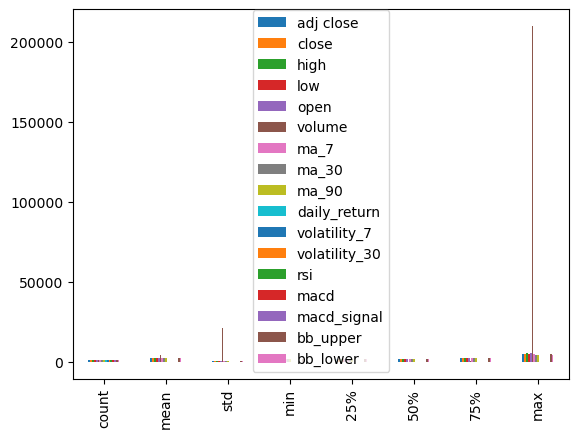

In [6]:
df.describe().plot(kind='bar')

In [7]:
df.isnull().sum()

date             0
adj close        0
close            0
high             0
low              0
open             0
volume           0
ma_7             0
ma_30            0
ma_90            0
daily_return     0
volatility_7     0
volatility_30    0
rsi              0
macd             0
macd_signal      0
bb_upper         0
bb_lower         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month 
df['month'].value_counts()

month
8     111
10    110
12    106
7     106
9     103
11    102
1     102
6      95
3      87
5      86
4      82
2      77
Name: count, dtype: int64

In [10]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year 
df['year'].value_counts()

year
2025    252
2024    252
2022    251
2023    250
2021    142
2026     20
Name: count, dtype: int64

In [11]:
df['date'] = pd.to_datetime(df['date'])
df['weekday'] = df['date'].dt.day_name()
df['weekday'].value_counts()

weekday
Tuesday      241
Wednesday    239
Friday       238
Thursday     233
Monday       216
Name: count, dtype: int64

In [12]:
df.dtypes


date             datetime64[ns]
adj close               float64
close                   float64
high                    float64
low                     float64
open                    float64
volume                    int64
ma_7                    float64
ma_30                   float64
ma_90                   float64
daily_return            float64
volatility_7            float64
volatility_30           float64
rsi                     float64
macd                    float64
macd_signal             float64
bb_upper                float64
bb_lower                float64
month                     int32
year                      int32
weekday                  object
dtype: object

<Figure size 1200x1200 with 0 Axes>

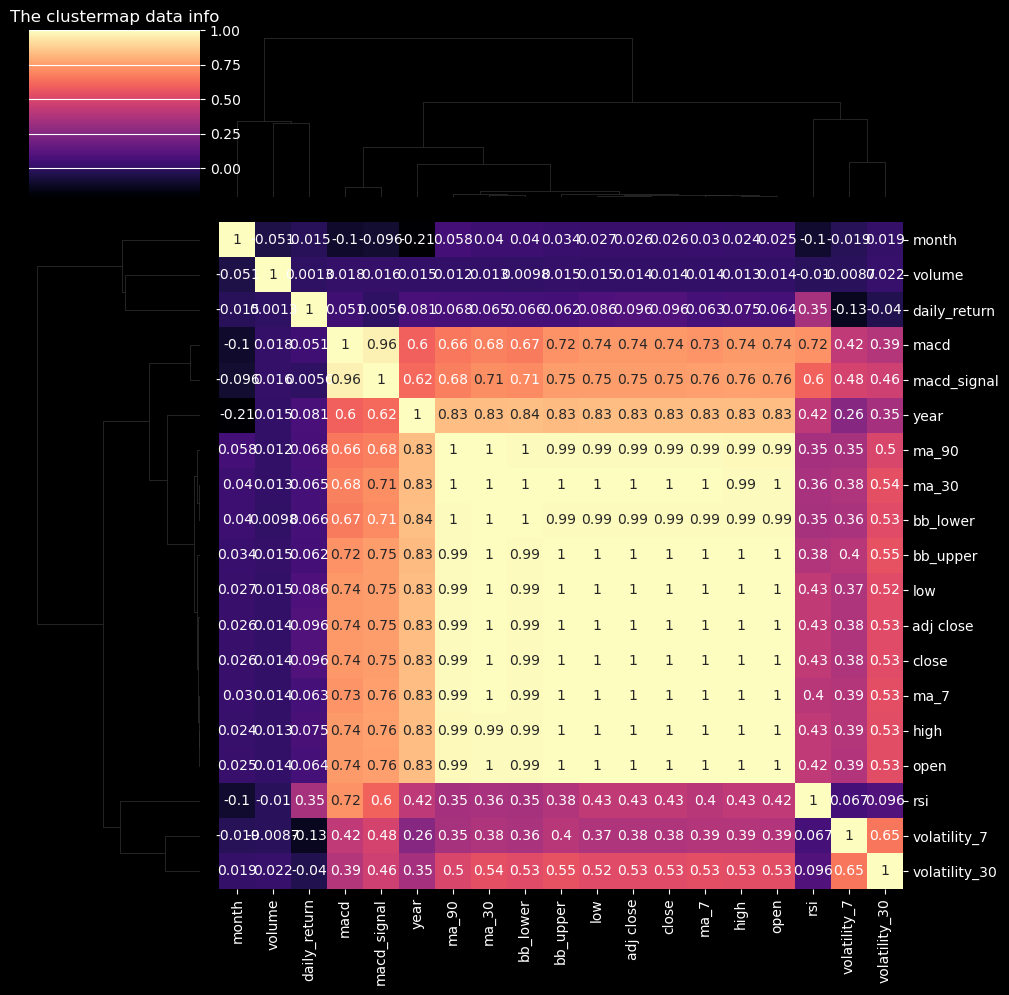

In [13]:
plt.figure(figsize=(12,12))
plt.style.use('dark_background')
sns.clustermap(df.corr(numeric_only=True),annot=True,cmap='magma')
plt.title('The clustermap data info')
plt.grid(True)
plt.tight_layout()
plt.show()

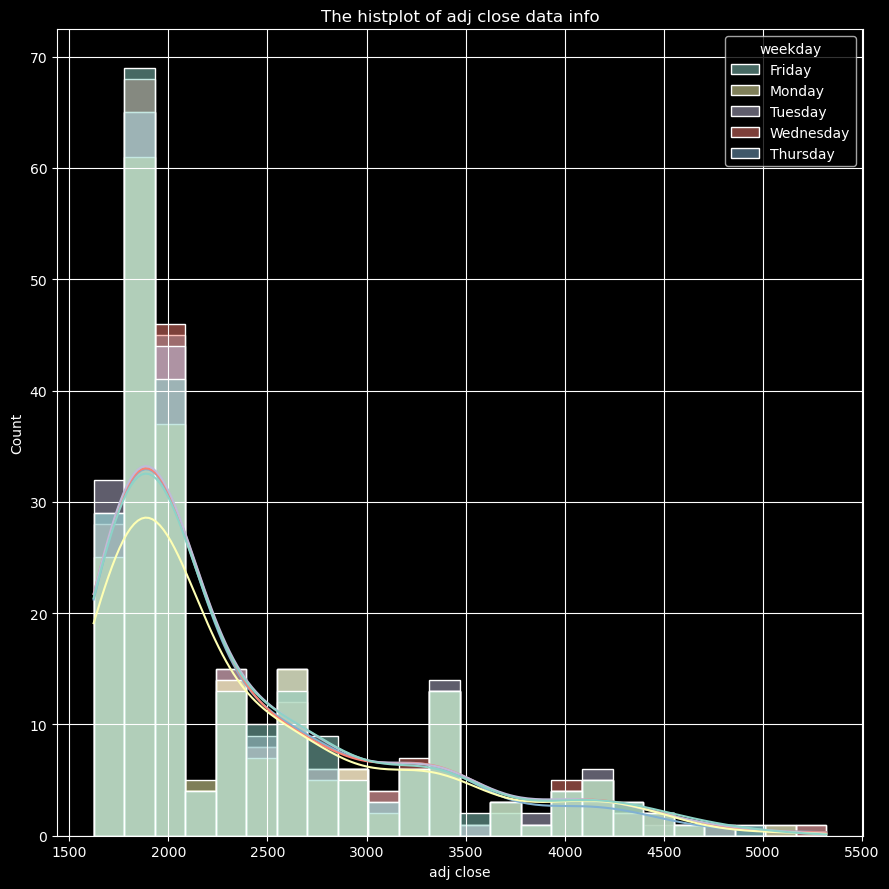

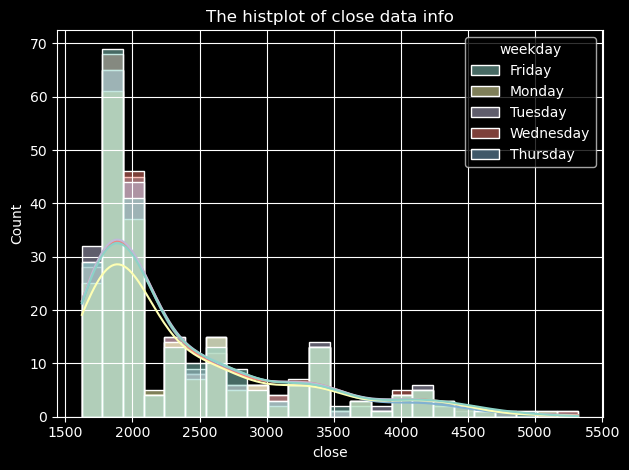

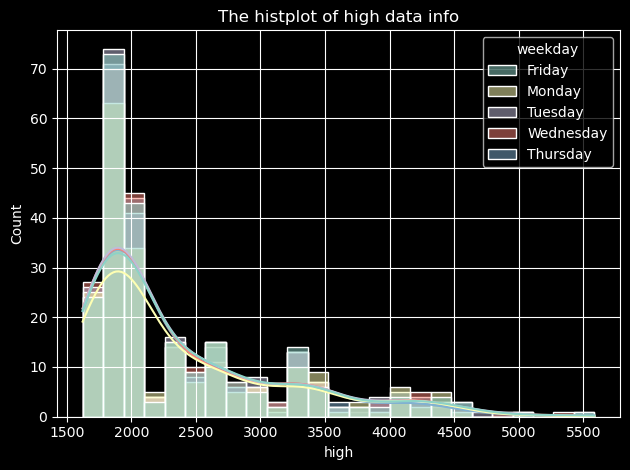

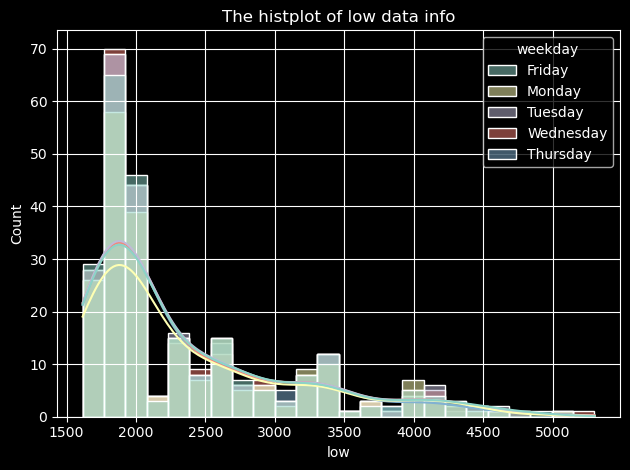

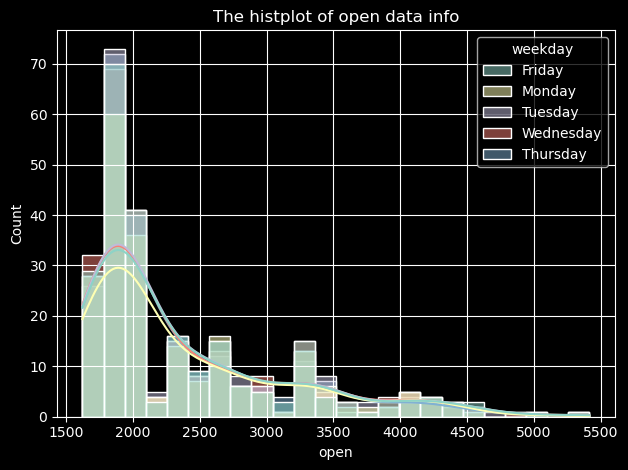

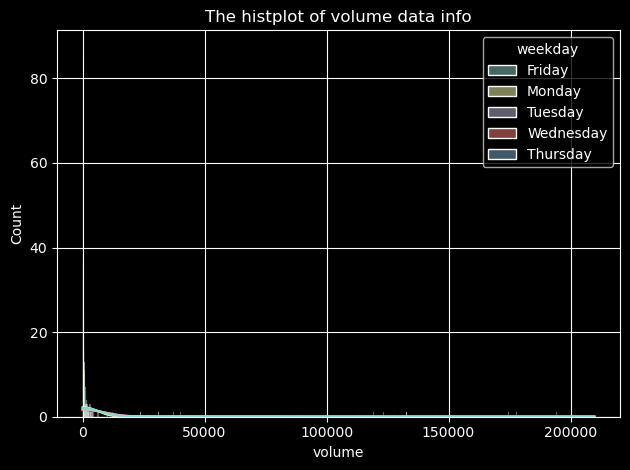

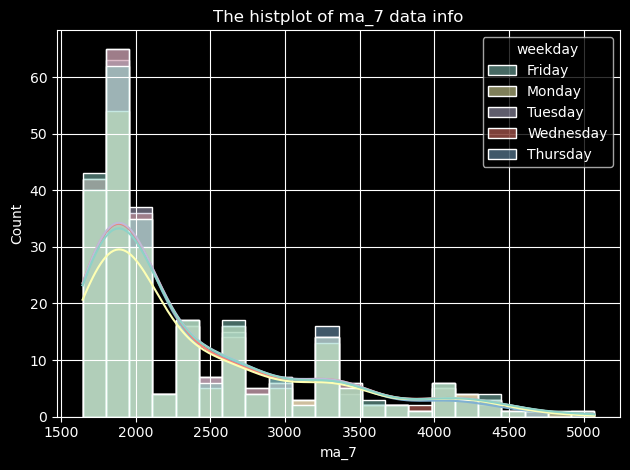

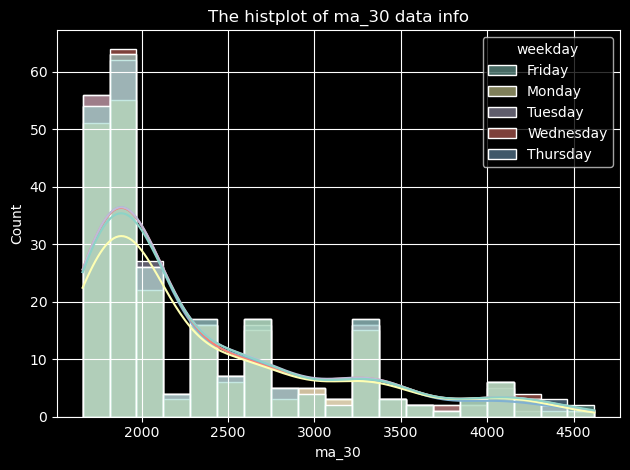

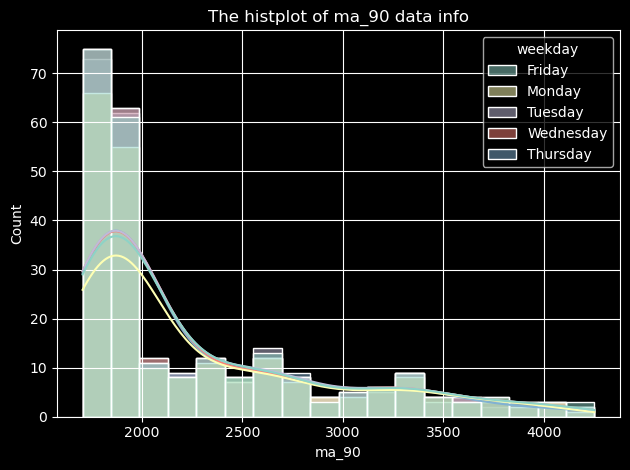

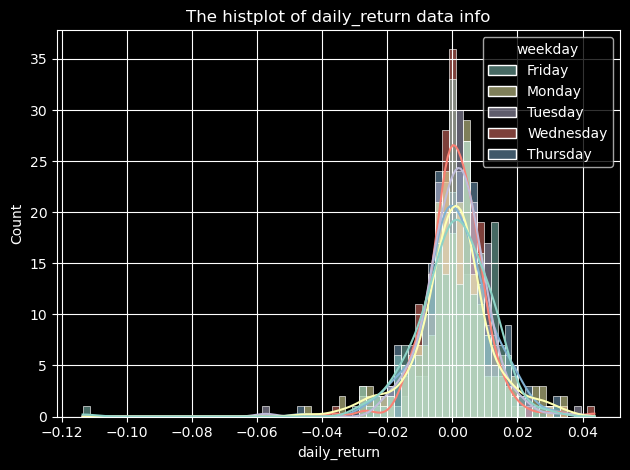

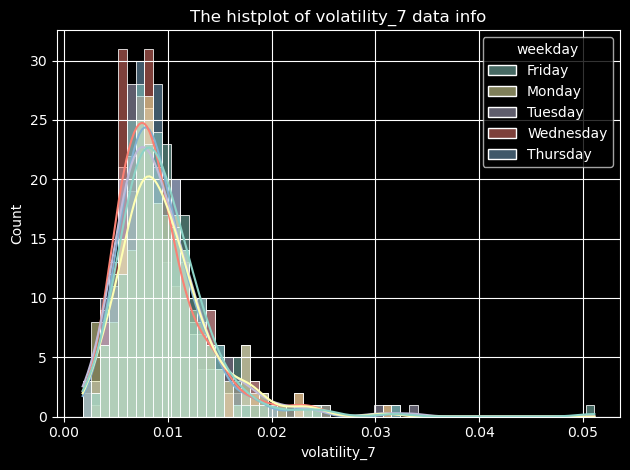

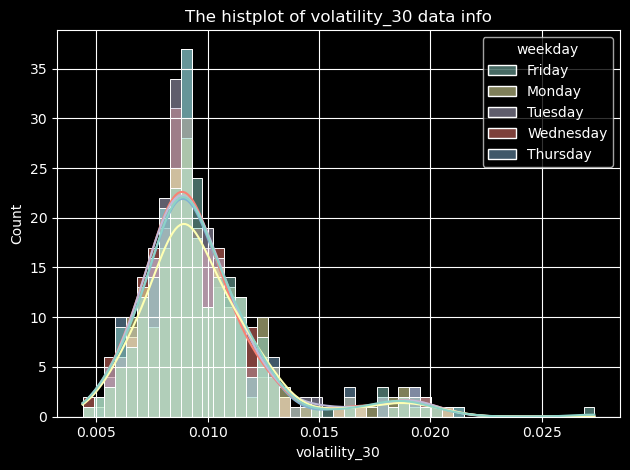

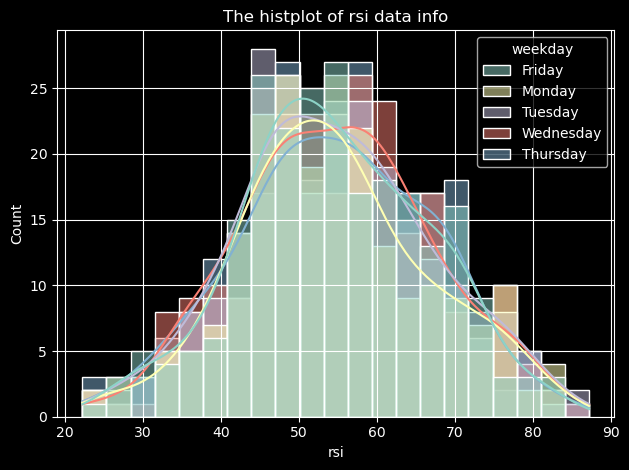

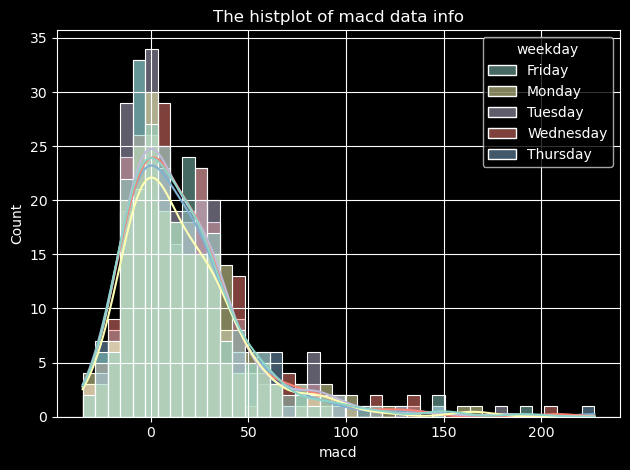

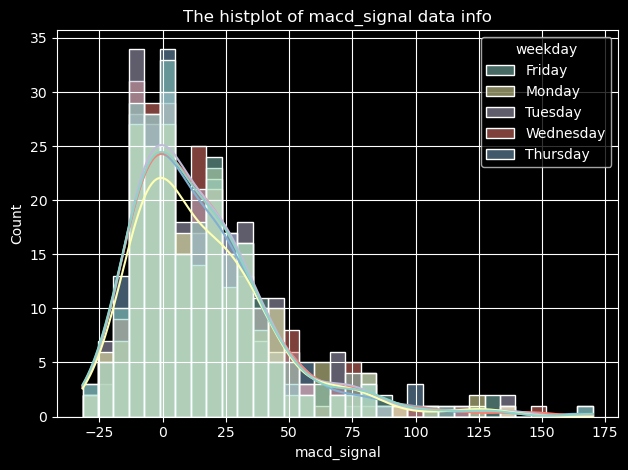

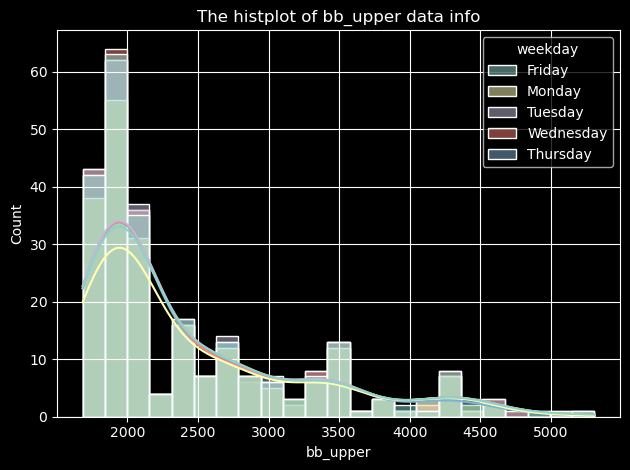

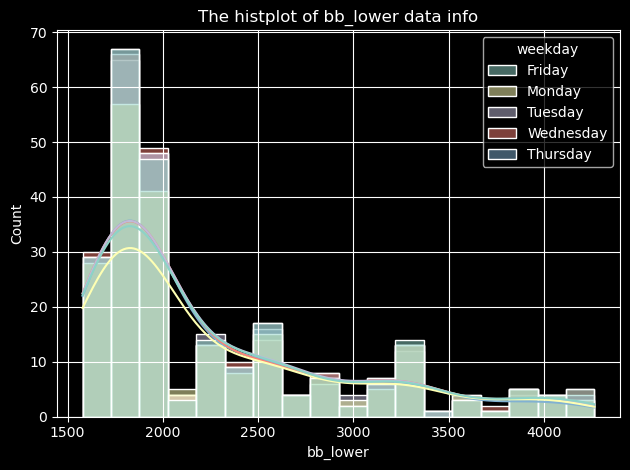

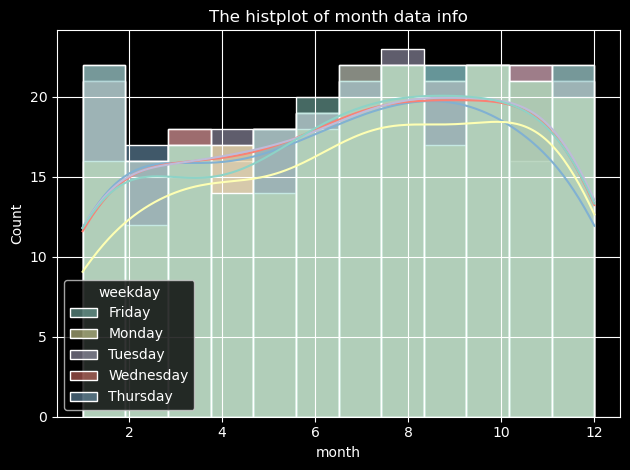

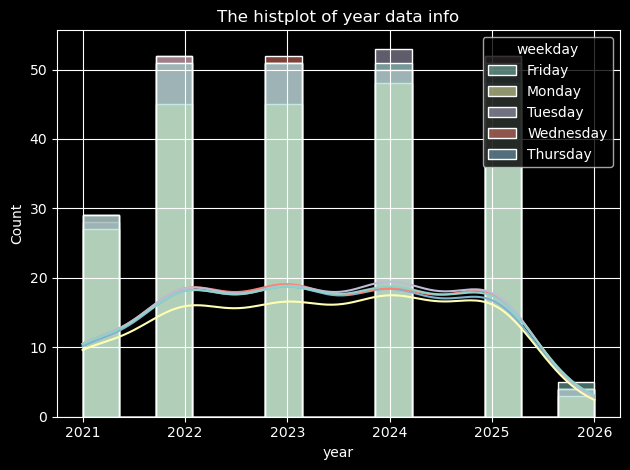

In [14]:
numerical_col = df.select_dtypes(include=np.number).columns 

plt.figure(figsize=(9,9))
for col in numerical_col:
    sns.histplot(data=df,x=col,kde=True,hue='weekday')
    plt.title(f'The histplot of {col} data info')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


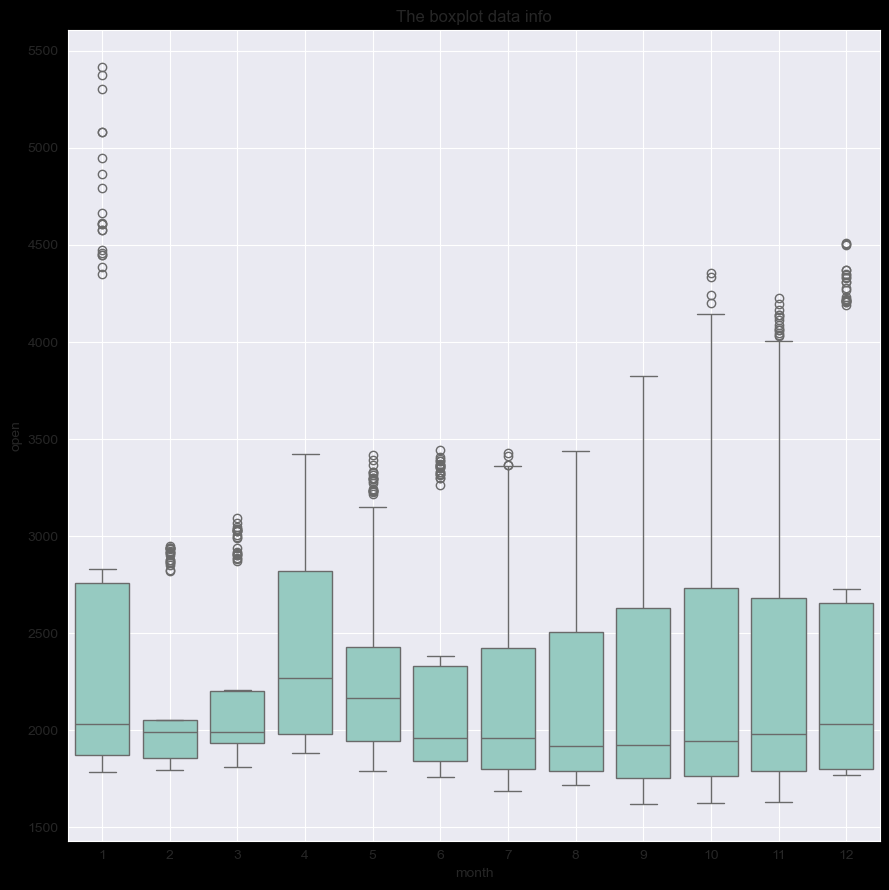

In [15]:
plt.figure(figsize=(9,9))
sns.set_style('darkgrid')
sns.boxplot(x='month',y='open',data=df)
plt.title('The boxplot data info')
plt.grid(True)
plt.tight_layout()
plt.show()

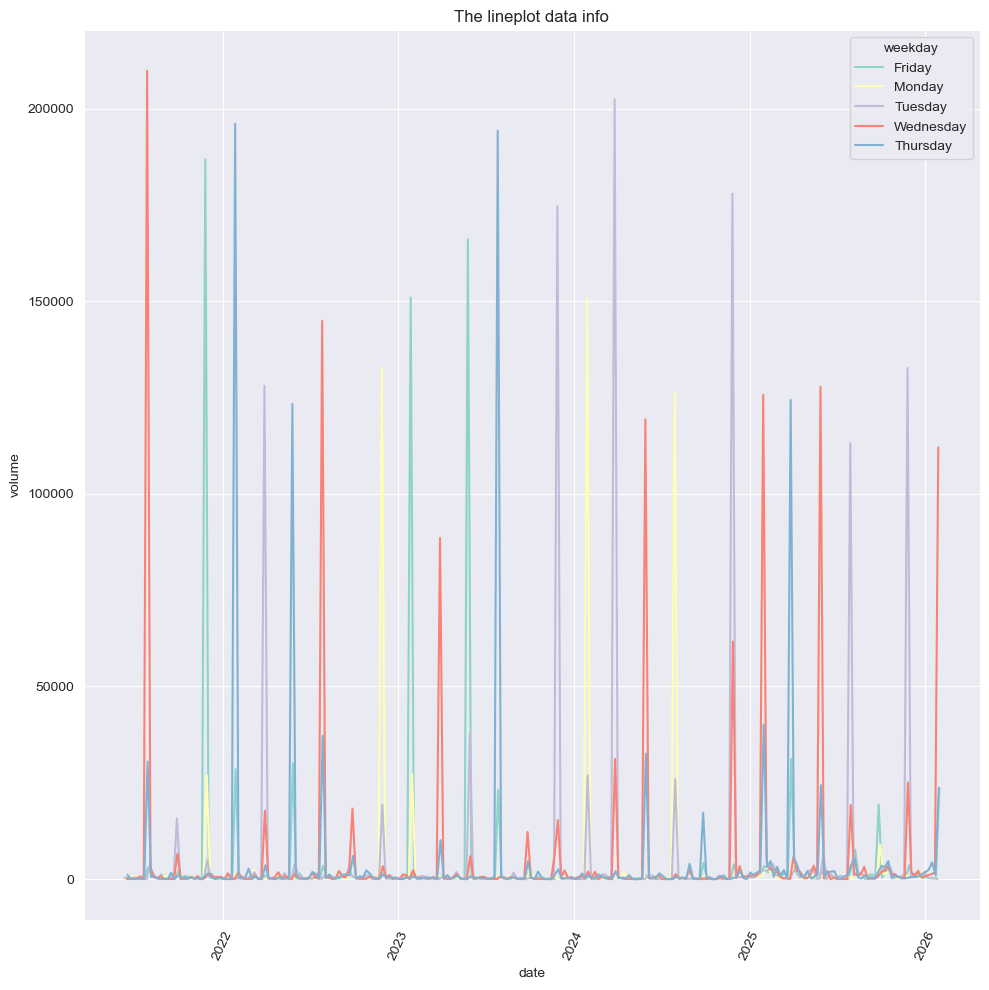

In [16]:
plt.figure(figsize=(10,10))
sns.set_style('darkgrid')
sns.lineplot(x='date',y='volume',data=df,hue='weekday')
plt.xticks(rotation=65)
plt.title('The lineplot data info')
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
X = df[['open','close','high','low']]
y = df['volume']

x_train,x_test,y_train,y_test = train_test_split(X,y, random_state=42,test_size=(0.3))

In [19]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [20]:
y_pred = model.predict(x_test)
y_pred

array([4983.72464197, 4383.94935946, 4405.22447361, 3247.14632987,
       4421.90243049, 3220.5960807 , 4171.54472233, 3622.67553578,
       4415.4433755 , 3180.27498511, 4246.43612663, 4755.8458961 ,
       5229.5561451 , 4428.19985054, 4058.72029106, 4815.03648303,
       1183.35663967, 4023.24752065, 4082.83797859, 2903.95584219,
       5125.63403656, 3272.9069544 , 3973.68844494, 3014.47087661,
       4363.79464327,  884.19912385, 3780.40099347, 4493.29988722,
       4623.46590532, 4479.97895341, 3520.94381114, 3938.74796975,
       6061.433133  , 4594.96878283, 4494.91359088, 4424.39881992,
       4294.87075042, 3756.58923572, 4489.09481499, 5789.33545949,
       5417.86473914, 4243.41872005, 4270.51440903, 4572.43817322,
       3711.24232339, 4568.75934256, 3616.04897069, 4375.97583065,
       4779.84455353, 5244.56807916, 4328.91986511, 5220.07866228,
       4419.89815841, 5461.87177857, 4525.03625666, 4579.33063927,
       3853.7404239 , -791.57285484, 4407.91638818, 3716.86490

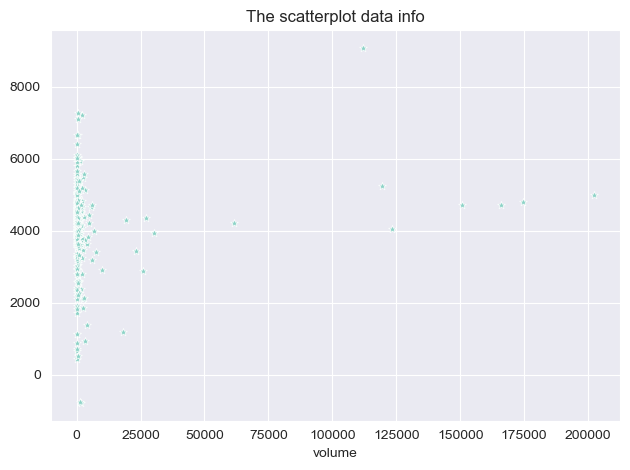

In [21]:
sns.set_style('darkgrid')
sns.scatterplot(x=y_test,y=y_pred,marker='*')
plt.title('The scatterplot data info')
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
mae = mean_absolute_error(y_pred,y_test)
mse = mean_squared_error(y_pred,y_test)
print('The mean absolute_error is:',mae),
print('The mean sqared error:',mse)

The mean absolute_error is: 6856.627806878056
The mean sqared error: 467003261.7060797


In [25]:
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [26]:
# HANDLE MISSING VALUES
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)
            